In [ ]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import ClippedAdam, Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

import time

In [ ]:
# Set random seed for reproducibility
pyro.set_rng_seed(42)

In [ ]:
# load the data
test_data_path = "small_test_data.csv"
test_label_path = "small_test_labels.csv"
test_data = pd.read_csv(test_data_path).values.astype(np.float32)
test_label = pd.read_csv(test_label_path).values

val_data_path = "small_val_data.csv"
val_label_path = "small_val_labels.csv"
val_data = pd.read_csv(val_data_path).values.astype(np.float32)
val_label = pd.read_csv(val_label_path).values

print("test_data shape:", test_data.shape)
print("test_label shape:", test_label.shape)

print(test_data[0,0:10])

test_data shape: (200, 400)
test_label shape: (200, 1)
[5.53000e-02 0.00000e+00 5.55492e+01 4.71580e+00 3.67360e+00 2.70879e+01
 1.88500e-01 1.50104e+01 1.45420e+01 1.54886e+01]


In [ ]:
X_train = test_data



# Z-score normalization per gene
X_train_mean = X_train.mean(axis=0)
X_train_std = X_train.std(axis=0) + 1e-6  # avoid div-by-zero
X_norm = (X_train - X_train_mean) / X_train_std
X_clipped = np.clip(X_norm, -5, 5)

X_train_tensor = torch.tensor(X_clipped, dtype=torch.float32)


print(X_train_tensor[0,0:10])

tensor([-0.3517, -0.2533, -0.2346, -0.3010, -0.4803, -0.4995, -0.2547, -0.1780,
         0.0544, -1.0121])


In [ ]:
latent_dim = 20  # can be 10–50 depending on dataset
n_samples, n_genes = X_train.shape
sigma_w = pyro.sample("sigma_w", dist.HalfCauchy(1.))


W_model = dist.Normal(0., sigma_w).expand([n_genes]).to_event(1)
print("W in model batch shape:", W_model.batch_shape)
print("W in model event shape:", W_model.event_shape)

W in model batch shape: torch.Size([])
W in model event shape: torch.Size([400])


In [89]:
w_loc = pyro.param("w_loc", torch.randn(latent_dim, n_genes))
w_scale = pyro.param("w_scale", torch.ones(latent_dim, n_genes) * 0.1, constraint=dist.constraints.positive)


W_guide = dist.Normal(w_loc, w_scale).to_event(1)
print("W in guide batch shape:", W_guide.batch_shape)
print("W in guide event shape:", W_guide.event_shape)


W in guide batch shape: torch.Size([20])
W in guide event shape: torch.Size([400])


In [94]:
latent_dim = 20  # can be 10–50 depending on dataset
n_samples, n_genes = X_train_tensor.shape

def model(X):
    sigma_w = pyro.sample("sigma_w", dist.HalfCauchy(1.))
    
    # Sample W as a full matrix: [latent_dim, n_genes]
    W = pyro.sample("W", dist.Normal(0., sigma_w).expand([latent_dim, n_genes]).to_event(2))

    with pyro.plate("data", n_samples):
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))  # [n_samples, latent_dim]
        x_loc = torch.matmul(z, W)  # [n_samples, n_genes]
        pyro.sample("obs", dist.Normal(x_loc, 0.1).to_event(1), obs=X)


In [95]:
def guide(X):
    # W variational params: [latent_dim, n_genes]
    w_loc = pyro.param("w_loc", torch.randn(latent_dim, n_genes))
    w_scale = pyro.param("w_scale", torch.ones(latent_dim, n_genes) * 0.1,
                         constraint=dist.constraints.positive)
    sigma_w_q = pyro.param("sigma_w_q", torch.tensor(1.), constraint=dist.constraints.positive)

    pyro.sample("sigma_w", dist.Delta(sigma_w_q))
    pyro.sample("W", dist.Normal(w_loc, w_scale).to_event(2))

    # z variational: [n_samples, latent_dim]
    z_loc = pyro.param("z_loc", torch.randn(n_samples, latent_dim))
    z_scale = pyro.param("z_scale", torch.ones(n_samples, latent_dim) * 0.1,
                         constraint=dist.constraints.positive)

    with pyro.plate("data", n_samples):
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))


In [ ]:
pyro.clear_param_store()
optimizer = ClippedAdam({"lr": 0.01})
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

start_time = time.time()

n_steps = 3000
for step in range(n_steps):
    loss = svi.step(X_train_tensor)
    if step % 200 == 0:
        print(f"[Step {step}] Loss: {loss:.2f}")


# Total time spent
print(f"Total time spent: {time.time() - start_time:.2f} seconds")
print(f"Total time spent: {((time.time() - start_time) / 60):.2f} minutes")

[Step 0] Loss: 84052425.07
[Step 200] Loss: 1643543.26
[Step 400] Loss: 1008099.21
[Step 600] Loss: 939369.19
[Step 800] Loss: 932982.87
[Step 1000] Loss: 930674.21
[Step 1200] Loss: 930636.87
[Step 1400] Loss: 930274.08
[Step 1600] Loss: 930276.55
[Step 1800] Loss: 930230.20
[Step 2000] Loss: 930018.14
[Step 2200] Loss: 930036.21
[Step 2400] Loss: 929865.32
[Step 2600] Loss: 929847.67
[Step 2800] Loss: 929913.81


In [100]:
# Extract latent space
z_loc = pyro.param("z_loc").detach().numpy()  # [n_samples, latent_dim]

# Extract gene loadings
w_loc = pyro.param("w_loc").detach().numpy()  # [latent_dim, n_genes]

# Influence of each gene in each latent dimension
gene_importance = np.abs(w_loc).mean(axis=0)  # Mean abs weight per gene

# Top 10 genes
top_gene_indices = np.argsort(-gene_importance)[:10]

# Create a DataFrame for better visualization
df_genes = pd.DataFrame(X_train_tensor.numpy(), columns=[f"Gene_{i}" for i in range(n_genes)])

top_genes = df_genes.columns[top_gene_indices]
df_genes[top_genes].head(10)  # Display top 10 genes


,Gene_316,Gene_222,Gene_298,Gene_216,Gene_149,Gene_335,Gene_69,Gene_13,Gene_21,Gene_76
0,-0.294657,-0.377263,0.639004,-0.138634,1.284618,1.457217,0.003238,-0.325896,-1.229725,0.292985
1,-0.322130,-0.645950,-1.023668,0.358706,-0.003016,0.669675,-0.354504,-0.135444,0.368820,-1.152157
2,1.331692,0.480031,0.871605,-1.018045,-0.197435,-0.409347,5.000000,0.337258,0.162480,-0.770419
3,-0.329116,-0.560340,-0.725630,-0.632808,-0.534746,-1.116449,-0.392415,-0.721755,-0.935712,0.386477
4,-0.328998,-0.275530,-0.558854,0.327686,-0.356811,-0.357322,-0.410444,-0.696826,0.660182,0.868196
5,2.962554,1.889333,0.046988,-1.377621,-0.694606,-0.755695,-0.221898,2.422622,-0.548250,-0.787681
6,-0.329137,-0.161482,-0.530723,1.946839,-0.355259,1.265165,-0.446970,-0.836752,-0.682824,0.732945
7,-0.329354,-0.283766,-0.483105,-0.802292,0.112131,-0.370377,-0.439564,-0.405889,0.190850,-0.067807
8,-0.315234,0.937962,-0.771021,-0.681558,-0.043019,-0.552572,-0.355317,-0.748030,-0.186418,-0.593734
9,-0.322603,-0.593365,0.849733,0.326355,0.273487,0.432121,-0.155891,0.767129,0.885613,-0.430569


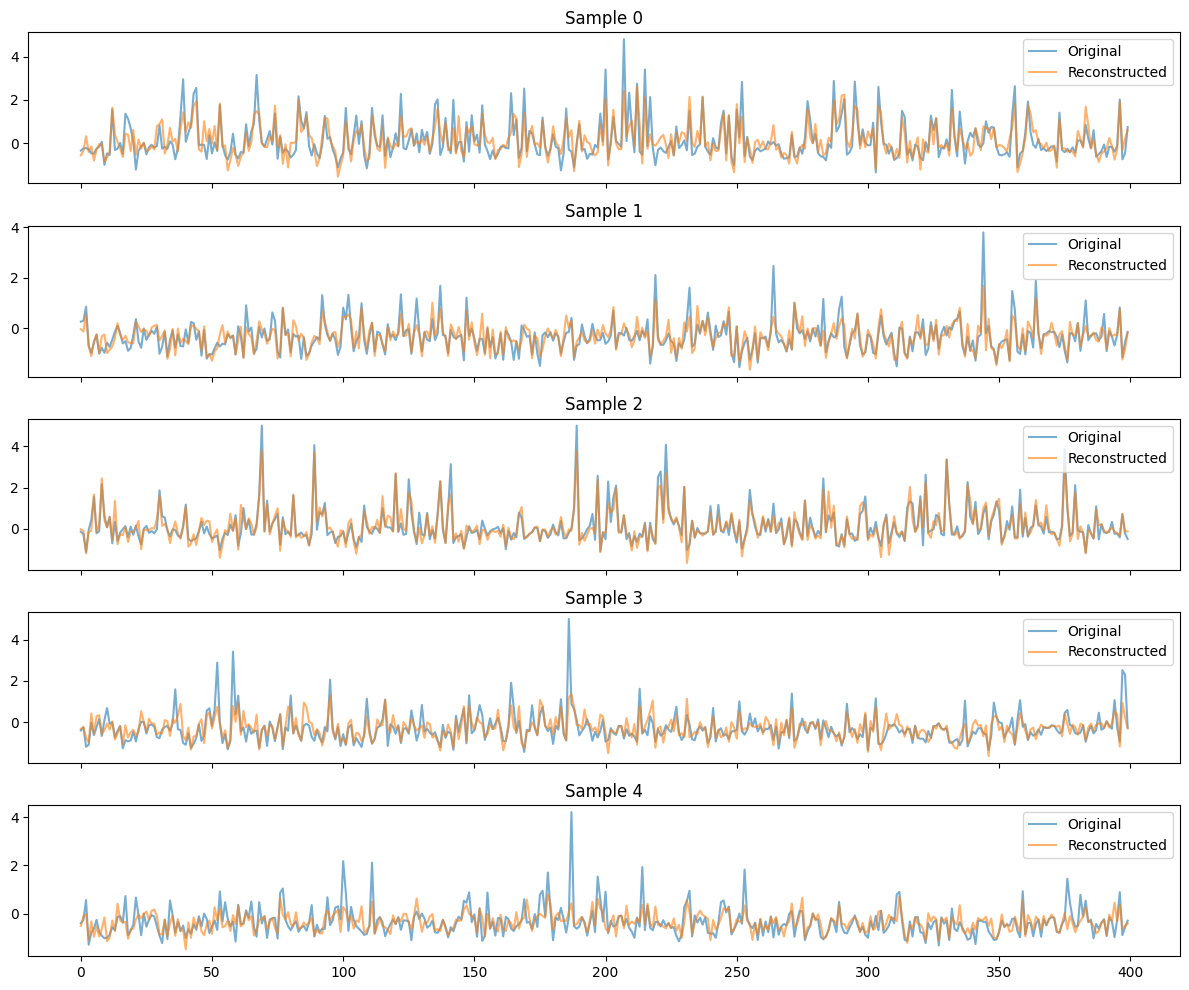

In [104]:
# Reconstruct X using the variational means
with torch.no_grad():
    z_loc = pyro.param("z_loc")        # [n_samples, latent_dim]
    w_loc = pyro.param("w_loc")        # [latent_dim, n_genes]
    X_recon = torch.matmul(z_loc, w_loc)  # [n_samples, n_genes]

# Compare a few samples
n_plot = 5
fig, axs = plt.subplots(n_plot, 1, figsize=(12, 2 * n_plot), sharex=True)

for i in range(n_plot):
    axs[i].plot(X_train_tensor[i].numpy(), label="Original", alpha=0.6)
    axs[i].plot(X_recon[i].numpy(), label="Reconstructed", alpha=0.6)
    axs[i].set_title(f"Sample {i}")
    axs[i].legend(loc="upper right")

plt.tight_layout()
plt.show()

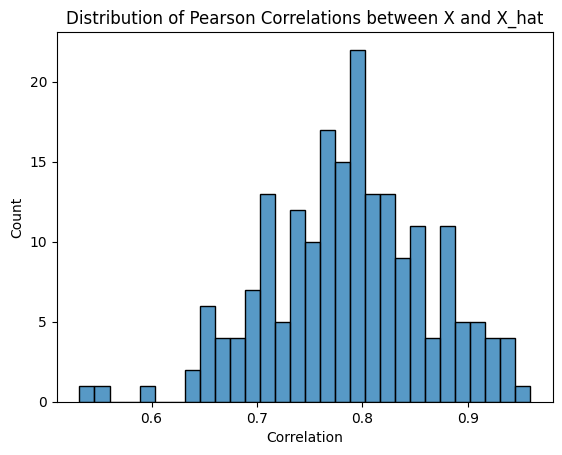

In [107]:
# Measure the linear correlation between the original and reconstructed data
correlations = []
for i in range(X_train.shape[0]):
    corr, _ = pearsonr(X_train[i].numpy(), X_recon[i].numpy())
    correlations.append(corr)

sns.histplot(correlations, bins=30)
plt.title("Distribution of Pearson Correlations between X and X_hat")
plt.xlabel("Correlation")
plt.show()

### STEP 2 - Classification

In [108]:
n_classes = 3  # AML, ALL, Normal

def classifier_model(z, y=None):
    weight = pyro.sample("weight", dist.Normal(0., 1.).expand([n_classes, latent_dim]).to_event(2))
    bias = pyro.sample("bias", dist.Normal(0., 10.).expand([n_classes]).to_event(1))

    logits = torch.matmul(z, weight.T) + bias  # shape: [n_samples, n_classes]

    with pyro.plate("data", z.shape[0]):
        pyro.sample("obs", dist.Categorical(logits=logits), obs=y)


In [ ]:
def classifier_guide(z, y=None):
    weight_loc = pyro.param("weight_loc", torch.randn(n_classes, latent_dim))
    weight_scale = pyro.param("weight_scale", torch.ones(n_classes, latent_dim) * 0.1, constraint=dist.constraints.positive)
    bias_loc = pyro.param("bias_loc", torch.randn(n_classes))
    bias_scale = pyro.param("bias_scale", torch.ones(n_classes) * 0.1, constraint=dist.constraints.positive)

    pyro.sample("weight", dist.Normal(weight_loc, weight_scale).to_event(2))
    pyro.sample("bias", dist.Normal(bias_loc, bias_scale).to_event(1))

In [ ]:
# Make sure labels are in torch format and of type long
y_train_tensor = torch.tensor(test_label, dtype=torch.long)


classifier_svi = SVI(classifier_model, classifier_guide, Adam({"lr": 0.01}), loss=Trace_ELBO())


y_train_tensor = y_train_tensor.squeeze(-1) # [batch_size, 1] -> [batch_size]

start_time = time.time()

# Train
n_steps = 2000
for step in range(n_steps):
    loss = classifier_svi.step(z_loc.detach(), y_train_tensor)
    if step % 200 == 0:
        print(f"[Step {step}] Loss: {loss:.2f}")

# Total time spent
print(f"Total time spent: {time.time() - start_time:.2f} seconds")
print(f"Total time spent: {((time.time() - start_time) / 60):.2f} minutes")


[Step 0] Loss: 489.86
[Step 200] Loss: 99.82
[Step 400] Loss: 64.23
[Step 600] Loss: 79.15
[Step 800] Loss: 80.51
[Step 1000] Loss: 64.98
[Step 1200] Loss: 73.41
[Step 1400] Loss: 68.82
[Step 1600] Loss: 68.08
[Step 1800] Loss: 79.38


In [ ]:
# Use mean of variational posterior for prediction
with torch.no_grad():
    w = pyro.param("weight_loc")
    b = pyro.param("bias_loc")
    logits = torch.matmul(z_loc, w.T) + b
    y_pred = torch.argmax(logits, dim=1)

print(classification_report(y_train_tensor, y_pred.numpy(), target_names=["AML", "ALL", "Normal"]))

              precision    recall  f1-score   support

         AML       0.98      0.99      0.99       118
         ALL       1.00      1.00      1.00        67
      Normal       0.93      0.87      0.90        15

    accuracy                           0.98       200
   macro avg       0.97      0.95      0.96       200
weighted avg       0.98      0.98      0.98       200



c:\Users\kgl07\anaconda3\envs\course42186\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


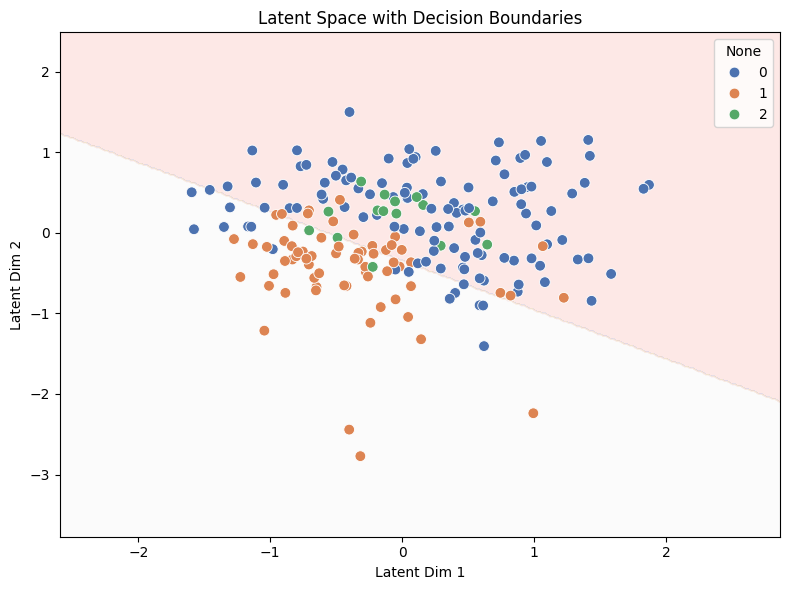

In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# Step 1: Reduce latent z_loc to 2D
pca = PCA(n_components=2)
z_2d = pca.fit_transform(z_loc.detach().numpy())  # shape: [n_samples, 2]

# Step 2: Fit softmax classifier in this 2D space using the PCA-reduced z
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs')
clf.fit(z_2d, y_train_tensor)

# Step 3: Plot decision boundaries
def plot_decision_boundary(clf, X, y, ax):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the boundary
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='Pastel1')

    # Scatter plot of the points
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, ax=ax, palette="deep", s=60)
    ax.set_title("Latent Space with Decision Boundaries")
    ax.set_xlabel("Latent Dim 1")
    ax.set_ylabel("Latent Dim 2")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
plot_decision_boundary(clf, z_2d, y_train_tensor, ax)
plt.tight_layout()
plt.show()


In [123]:
X_val = (val_data - X_train_mean) / X_train_std
X_val = np.clip(X_val, -5, 5)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(val_label, dtype=torch.long)

In [124]:
with torch.no_grad():
    w_loc = pyro.param("w_loc")  # shape: [latent_dim, n_genes]
    z_val = torch.matmul(X_val_tensor, w_loc.T)  # [n_samples_val, latent_dim]

In [131]:
with torch.no_grad():
    w = pyro.param("weight_loc")  # shape: [n_classes, latent_dim]
    b = pyro.param("bias_loc")    # shape: [n_classes]
    logits_val = torch.matmul(z_val, w.T) + b
    y_val_pred = torch.argmax(logits_val, dim=1)

print(classification_report(y_val_tensor, y_val_pred.numpy(), target_names=["AML", "ALL", "Normal"]))
print(f"Accuracy score for validation data set", accuracy_score(y_val_tensor, y_val_pred.numpy()))

              precision    recall  f1-score   support

         AML       0.95      0.69      0.80       118
         ALL       0.81      0.96      0.88        68
      Normal       0.37      0.93      0.53        14

    accuracy                           0.80       200
   macro avg       0.71      0.86      0.74       200
weighted avg       0.86      0.80      0.81       200

Accuracy score for validation data set 0.795


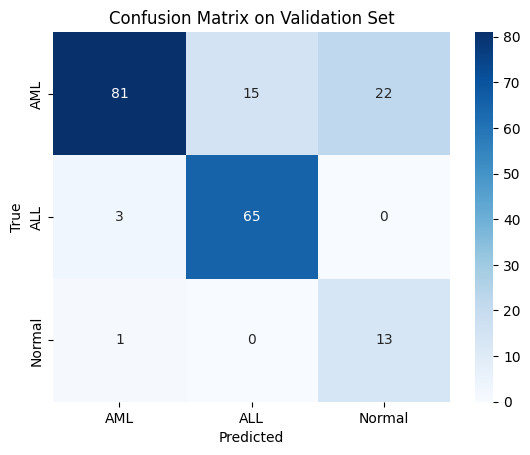

In [ ]:
cm = confusion_matrix(y_val_tensor, y_val_pred.numpy())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["AML", "ALL", "Normal"], yticklabels=["AML", "ALL", "Normal"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Validation Set")
plt.show()

### Step 3 - Gene importance per class

In [132]:
with torch.no_grad():
    W = pyro.param("w_loc")             # shape: [latent_dim, n_genes]
    classifier_w = pyro.param("weight_loc")  # shape: [n_classes, latent_dim]

    # Compute class-wise gene importance
    gene_importance = torch.matmul(classifier_w, W)  # shape: [n_classes, n_genes]



 Top genes for class: AML
       Gene  Importance      Effect
0    Gene_7    5.606209  Excitatory
1  Gene_218    4.224031  Excitatory
2   Gene_50    4.175368  Excitatory
3   Gene_33    4.117934  Excitatory
4  Gene_112    4.048998  Excitatory
5  Gene_197   -4.840277  Inhibitory
6  Gene_168   -4.334583  Inhibitory
7  Gene_178   -4.277834  Inhibitory
8  Gene_312   -4.160896  Inhibitory
9  Gene_128   -3.885106  Inhibitory


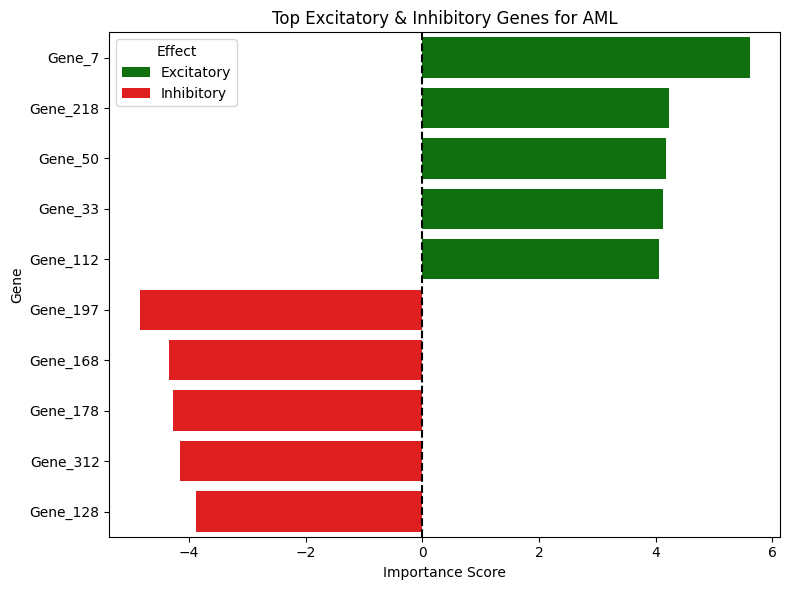


 Top genes for class: ALL
       Gene  Importance      Effect
0  Gene_178    5.286358  Excitatory
1  Gene_312    4.930838  Excitatory
2  Gene_128    4.801229  Excitatory
3  Gene_214    4.070021  Excitatory
4  Gene_275    3.939907  Excitatory
5  Gene_341   -5.458321  Inhibitory
6    Gene_7   -5.408976  Inhibitory
7  Gene_115   -4.963175  Inhibitory
8   Gene_67   -4.584663  Inhibitory
9   Gene_31   -4.511321  Inhibitory


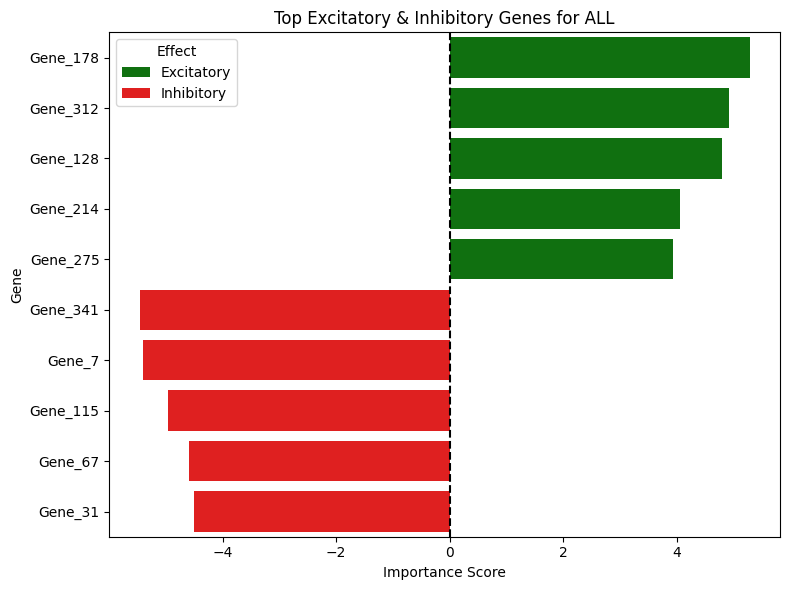


 Top genes for class: Normal
       Gene  Importance      Effect
0  Gene_189    4.953139  Excitatory
1   Gene_69    4.777432  Excitatory
2   Gene_89    4.736883  Excitatory
3  Gene_223    4.500644  Excitatory
4  Gene_330    4.348518  Excitatory
5  Gene_231   -2.358537  Inhibitory
6  Gene_216   -2.225938  Inhibitory
7  Gene_146   -1.936013  Inhibitory
8    Gene_2   -1.910101  Inhibitory
9   Gene_60   -1.832339  Inhibitory


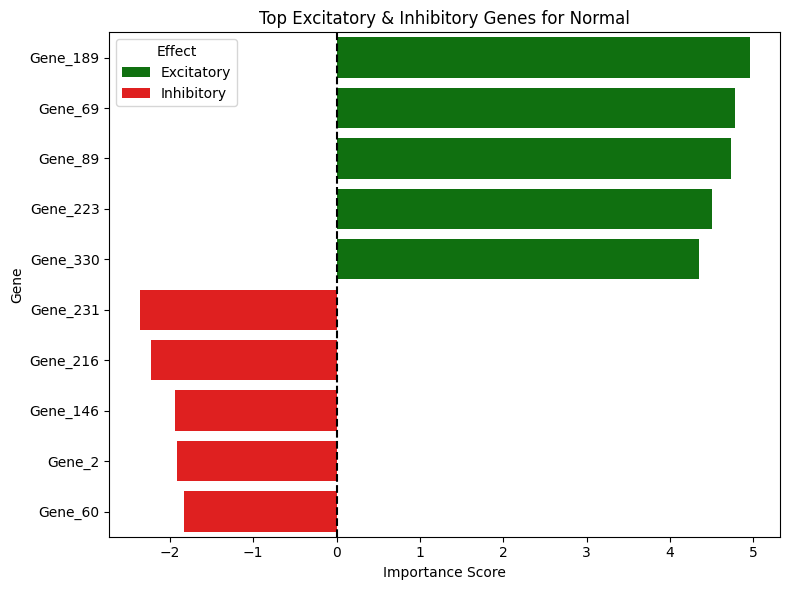

In [189]:
gene_names = df_genes.columns.values  # assuming your input genes have names in df_train

def get_signed_top_genes(importance_vector, gene_names, top_k=5):
    importance_np = importance_vector.detach().numpy()
    
    top_pos_idx = importance_np.argsort()[-top_k:][::-1]  # descending
    top_neg_idx = importance_np.argsort()[:top_k]         # ascending

    genes = [gene_names[i] for i in top_pos_idx] + [gene_names[i] for i in top_neg_idx]
    scores = list(importance_np[top_pos_idx]) + list(importance_np[top_neg_idx])
    effect = ['Excitatory'] * top_k + ['Inhibitory'] * top_k

    return pd.DataFrame({
        'Gene': genes,
        'Importance': scores,
        'Effect': effect
    })

# Plotting per class
for i, class_name in enumerate(["AML", "ALL", "Normal"]):
    df_plot = get_signed_top_genes(gene_importance[i], gene_names)

    print(f"\n Top genes for class: {class_name}")
    top_genes_df = get_signed_top_genes(gene_importance[i], gene_names)
    print(top_genes_df)
    
    plt.figure(figsize=(8, 6))
    sns.barplot(data=df_plot, x="Importance", y="Gene", hue="Effect", dodge=False, palette={"Excitatory": "green", "Inhibitory": "red"})
    plt.axvline(0, color='black', linestyle='--')
    plt.title(f"Top Excitatory & Inhibitory Genes for {class_name}")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()


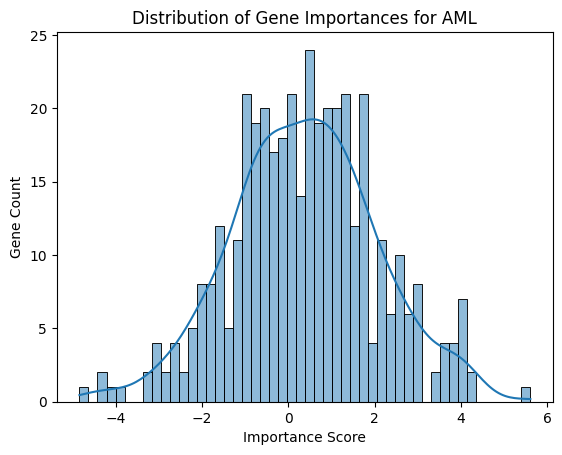

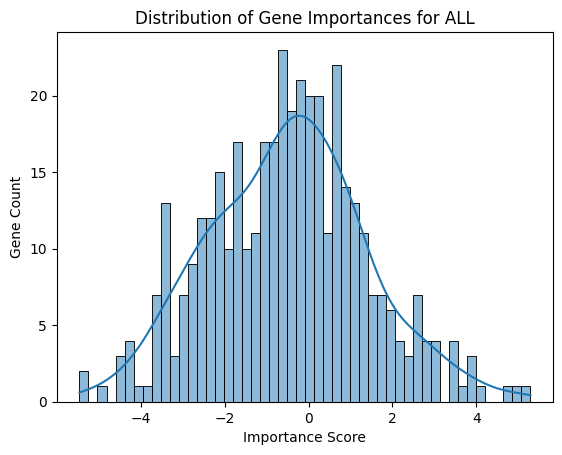

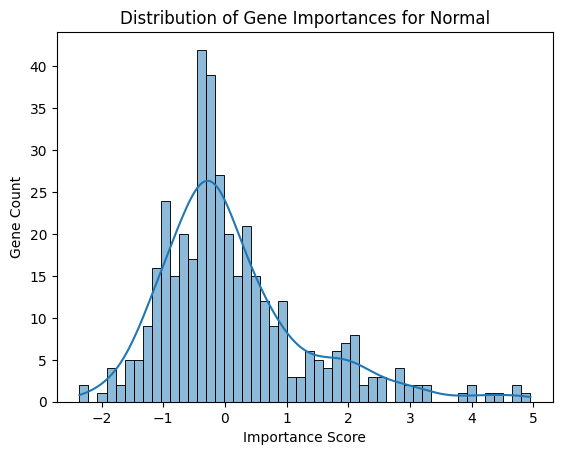

In [ ]:
for i, class_name in enumerate(["AML", "ALL", "Normal"]):
    sns.histplot(gene_importance[i].numpy(), bins=50, kde=True)
    plt.title(f"Distribution of Gene Importances for {class_name}")
    plt.xlabel("Importance Score")
    plt.ylabel("Gene Count")
    plt.show()